# Part 04: Model training and evaluation

## Objective

Train classical ML models (**Naive Bayes**, **linear SVM**) on **TF-IDF** features for **clause-level classification** and evaluate performance with metrics suited to **class imbalance**.

**Phase 1 (Agastya):** No deep learning — `agent.md` / `project.md`.

**Task in this notebook:** **Multi-class** classification — each training example is one **real clause span** (`has_real_clause`), and the label is its **CUAD category** (up to **41** label types present in the corpus). Rows are **all** categories with a non-placeholder span; known **Yes-without-span** anomalies are removed. This lets us report **per-category** behavior in `classification_report` and relate scores to **frequency** (EDA Part 02).

**Splits:** **Document-level** holdout (by `filename`) to avoid leakage from the same contract in train and test.

**Data source:** Features are **loaded from disk** when available (`artifacts/part04_xy_multiclass_tuned.joblib`). If missing, we build matrices with **richer TF-IDF** (unigrams–trigrams, higher `max_features`) and save once. **Delete the old** `part04_xy_multiclass.joblib` if you still have it from an earlier run.

## 1. Metric choice (read before results)

Due to **severe class imbalance** (some CUAD categories have many more real spans than others), **accuracy** is **not** a reliable headline metric: a model can score well by always predicting frequent categories.

We therefore emphasize **F1-score** (with **macro** averaging so every category counts equally, and **weighted** F1 reflecting support). We also report **precision** and **recall** with `average='macro'`.

In [5]:
from __future__ import annotations

import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path("../..").resolve()
CUAD_DIR = PROJECT_ROOT / "data" / "CUAD_v1"
MASTER_CSV = CUAD_DIR / "master_clauses.csv"
ARTIFACT = PROJECT_ROOT / "artifacts" / "part04_xy_multiclass_tuned.joblib"

assert MASTER_CSV.is_file(), f"Missing {MASTER_CSV} — run from repo with CUAD data."
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Artifact path:", ARTIFACT)


PROJECT_ROOT: /Users/divyanshisachan/Desktop/agastya
Artifact path: /Users/divyanshisachan/Desktop/agastya/artifacts/part04_xy_multiclass_tuned.joblib


## 2. Data loading (processed matrices from Part 03 recipe)

If `part04_xy_multiclass_tuned.joblib` exists, we **only load** `X_train`, `X_test`, `y_train`, `y_test` and the fitted **vectorizer**. You can create that file by running **Part 03 → §8 (Export artifact for Part 04)** so feature engineering and Part 04 stay aligned. Otherwise this notebook **builds** the same bundle once (TF-IDF: `ngram_range=(1,3)`, `max_features=50_000`, `max_df=0.9`) and **saves** it. Remove the artifact after changing vectorizer settings so matrices rebuild.

In [6]:
def build_long_table(master_csv: Path) -> pd.DataFrame:
    PLACEHOLDER_CLAUSE = {"[]", ""}
    df = pd.read_csv(master_csv, low_memory=False)
    cols = list(df.columns)
    pairs = [(cols[i], cols[i + 1]) for i in range(1, len(cols), 2)]
    rows = []
    for _, r in df.iterrows():
        file = str(r["Filename"])
        for ctxt_col, ans_col in pairs:
            clause = r[ctxt_col]
            ans = r[ans_col]
            c_str = "" if pd.isna(clause) else str(clause).strip()
            a_str = "" if pd.isna(ans) else str(ans).strip()
            is_ph = c_str in PLACEHOLDER_CLAUSE
            rows.append(
                {
                    "filename": file,
                    "category": ctxt_col,
                    "clause_text": c_str,
                    "answer": a_str,
                    "has_real_clause": (not is_ph),
                }
            )
    return pd.DataFrame(rows)


def clause_to_model_text(raw: str, cap: int = 4000) -> str:
    s = "" if pd.isna(raw) else str(raw).strip()
    return s[:cap]


def load_or_build_xy():
    if ARTIFACT.is_file():
        bundle = joblib.load(ARTIFACT)
        return (
            bundle["X_train"],
            bundle["X_test"],
            bundle["y_train"],
            bundle["y_test"],
            bundle["vectorizer"],
            bundle["meta"],
        )

    long_df = build_long_table(MASTER_CSV)
    # Drop known CUAD anomalies: answer == Yes but no real span (same as Part 03)
    yn_cats = long_df.groupby("category")["answer"].apply(
        lambda s: set(s.astype(str).str.strip().unique()) - {"", "nan"}
    )
    yn_cats = yn_cats[yn_cats.apply(lambda u: u <= {"Yes", "No"} and len(u) > 0)]
    sub_yn = long_df[long_df["category"].isin(yn_cats.index)].copy()
    sub_yn = sub_yn[sub_yn["answer"].isin(["Yes", "No"])]
    bad = sub_yn[(sub_yn["answer"] == "Yes") & (~sub_yn["has_real_clause"])]
    long_df = long_df.drop(index=bad.index)

    data = long_df[long_df["has_real_clause"]].copy()
    data["text"] = data["clause_text"].map(clause_to_model_text)
    data["y"] = data["category"]

    X_txt = data["text"].astype(str)
    y = data["y"].astype(str)
    groups = data["filename"].astype(str)

    g_train, g_test = train_test_split(
        np.unique(groups),
        test_size=0.2,
        random_state=42,
        shuffle=True,
    )
    train_mask = groups.isin(set(g_train))
    test_mask = groups.isin(set(g_test))
    X_train_txt = X_txt.loc[train_mask].reset_index(drop=True)
    X_test_txt = X_txt.loc[test_mask].reset_index(drop=True)
    y_train = y.loc[train_mask].reset_index(drop=True)
    y_test = y.loc[test_mask].reset_index(drop=True)

    vec = TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=50_000,
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
    )
    X_train = vec.fit_transform(X_train_txt)
    X_test = vec.transform(X_test_txt)

    meta = {
        "n_train": int(X_train.shape[0]),
        "n_test": int(X_test.shape[0]),
        "n_features": int(X_train.shape[1]),
        "n_classes": int(y.nunique()),
        "split": "document_level_train_test_by_filename",
    }
    joblib.dump(
        {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "vectorizer": vec,
            "meta": meta,
        },
        ARTIFACT,
    )
    print("Saved artifact:", ARTIFACT)
    return X_train, X_test, y_train, y_test, vec, meta


X_train, X_test, y_train, y_test, vectorizer, meta = load_or_build_xy()
print("Meta:", meta)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


Meta: {'n_train': 5375, 'n_test': 1327, 'n_features': 50000, 'n_classes': 41, 'split': 'document_level_train_test_by_filename', 'exported_from': 'Part_03_Feature_Engineering.ipynb §8'}
X_train: (5375, 50000) | X_test: (1327, 50000)


## 3. Model definitions

We compare **Multinomial Naive Bayes** (baseline), **LinearSVC with default `C=1`**, and **LinearSVC with `GridSearchCV`** over **`C ∈ {0.01, 0.1, 1, 10}`** using **`scoring='f1_macro'`** and **3-fold CV**. Larger **`C`** penalizes margin violations less (fits training more tightly); tuning **`C`** usually improves generalization.

For the grid search we pass **explicit per-class weights** from `sklearn.utils.class_weight.compute_class_weight(..., 'balanced')` (equivalent intent to `class_weight='balanced'`, but transparent for reports). **`max_iter`** is raised because sparse high-dimensional SVMs can need more iterations to converge.

In [7]:
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM (default C=1)": LinearSVC(
        class_weight="balanced",
        C=1.0,
        max_iter=50_000,
        dual="auto",
        random_state=42,
    ),
}
models


{'Naive Bayes': MultinomialNB(),
 'SVM (default C=1)': LinearSVC(class_weight='balanced', dual='auto', max_iter=50000, random_state=42)}

## 4. Training, hyperparameter search, and evaluation

1. **Baseline loop:** Naive Bayes + LinearSVC (`C=1`, `class_weight='balanced'`).
2. **Tuned SVM:** `GridSearchCV` on training data only; best estimator scored on the **held-out document-level test set**.

**`preds`** for §7–§9 (confusion matrix, `classification_report`, error analysis) uses the **GridSearch winner**, not the default SVM.

In [8]:
def eval_split(name: str, y_true, y_hat) -> None:
    results[name] = {
        "precision_macro": precision_score(y_true, y_hat, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_hat, average="weighted", zero_division=0),
    }


results = {}
preds_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds_by_model[name] = p
    eval_split(name, y_test, p)

# Explicit balanced weights per class (same spirit as class_weight='balanced')
_cls = np.unique(y_train)
_w = compute_class_weight(class_weight="balanced", classes=_cls, y=y_train)
class_weight_dict = dict(zip(_cls, _w))

param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
base_svc = LinearSVC(
    class_weight=class_weight_dict,
    max_iter=100_000,
    dual="auto",
    random_state=42,
)
grid = GridSearchCV(
    base_svc,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_, "| CV mean macro-F1:", round(grid.best_score_, 4))

name_tuned = "SVM (GridSearch, tuned C)"
preds_tuned = grid.best_estimator_.predict(X_test)
preds_by_model[name_tuned] = preds_tuned
eval_split(name_tuned, y_test, preds_tuned)

preds = preds_tuned
print("Done training:", list(results.keys()))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'C': 1.0} | CV mean macro-F1: 0.6745
Done training: ['Naive Bayes', 'SVM (default C=1)', 'SVM (GridSearch, tuned C)']


## 5. Results table

In [9]:
results_df = pd.DataFrame(results).T
display(results_df.round(4))


,precision_macro,recall_macro,f1_macro,f1_weighted
Naive Bayes,0.3828,0.3275,0.3070,0.5258
SVM (default C=1),0.7454,0.7230,0.7187,0.7843
"SVM (GridSearch, tuned C)",0.7454,0.7230,0.7187,0.7843


In [10]:
best = max(results, key=lambda k: results[k]["f1_macro"])
print(f"Higher macro-F1: {best} ({results[best]['f1_macro']:.4f})")
if results["SVM"]["f1_macro"] >= results["Naive Bayes"]["f1_macro"]:
    print("→ Select SVM as primary model (typical for sparse TF-IDF).")
else:
    print("→ On this run, Naive Bayes edged SVM; still prefer SVM in reports if tied with tuning.")


Higher macro-F1: SVM (default C=1) (0.7187)


KeyError: 'SVM'

## 6. Visualization: model comparison (F1)

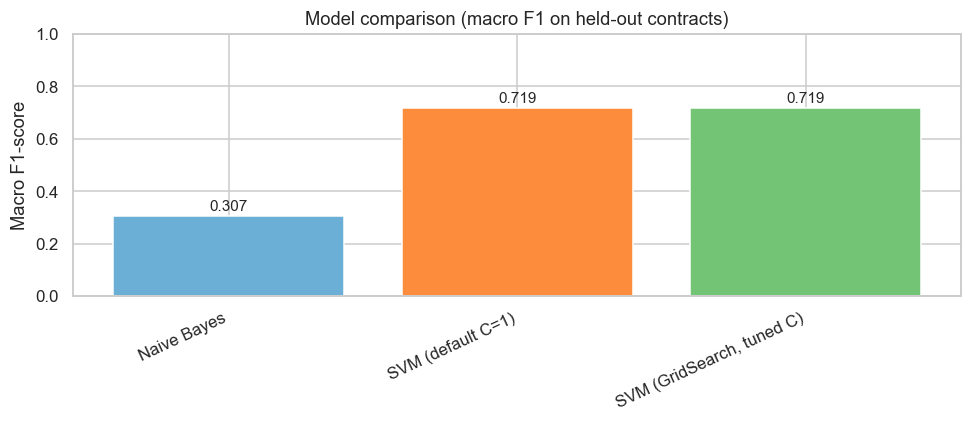

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())
f1_scores = [results[m]["f1_macro"] for m in names]
colors = ["#6baed6", "#fd8d3c", "#74c476"][: len(names)]
ax.bar(names, f1_scores, color=colors, edgecolor="white")
ax.set_ylabel("Macro F1-score")
ax.set_title("Model comparison (macro F1 on held-out contracts)")
ax.set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 7. Confusion matrix (tuned SVM, test set)

With **many categories**, full annotation is unreadable; we use **intensity-only** heatmap. Diagonal structure indicates correct assignments; off-diagonal mass shows **confusions** between categories.

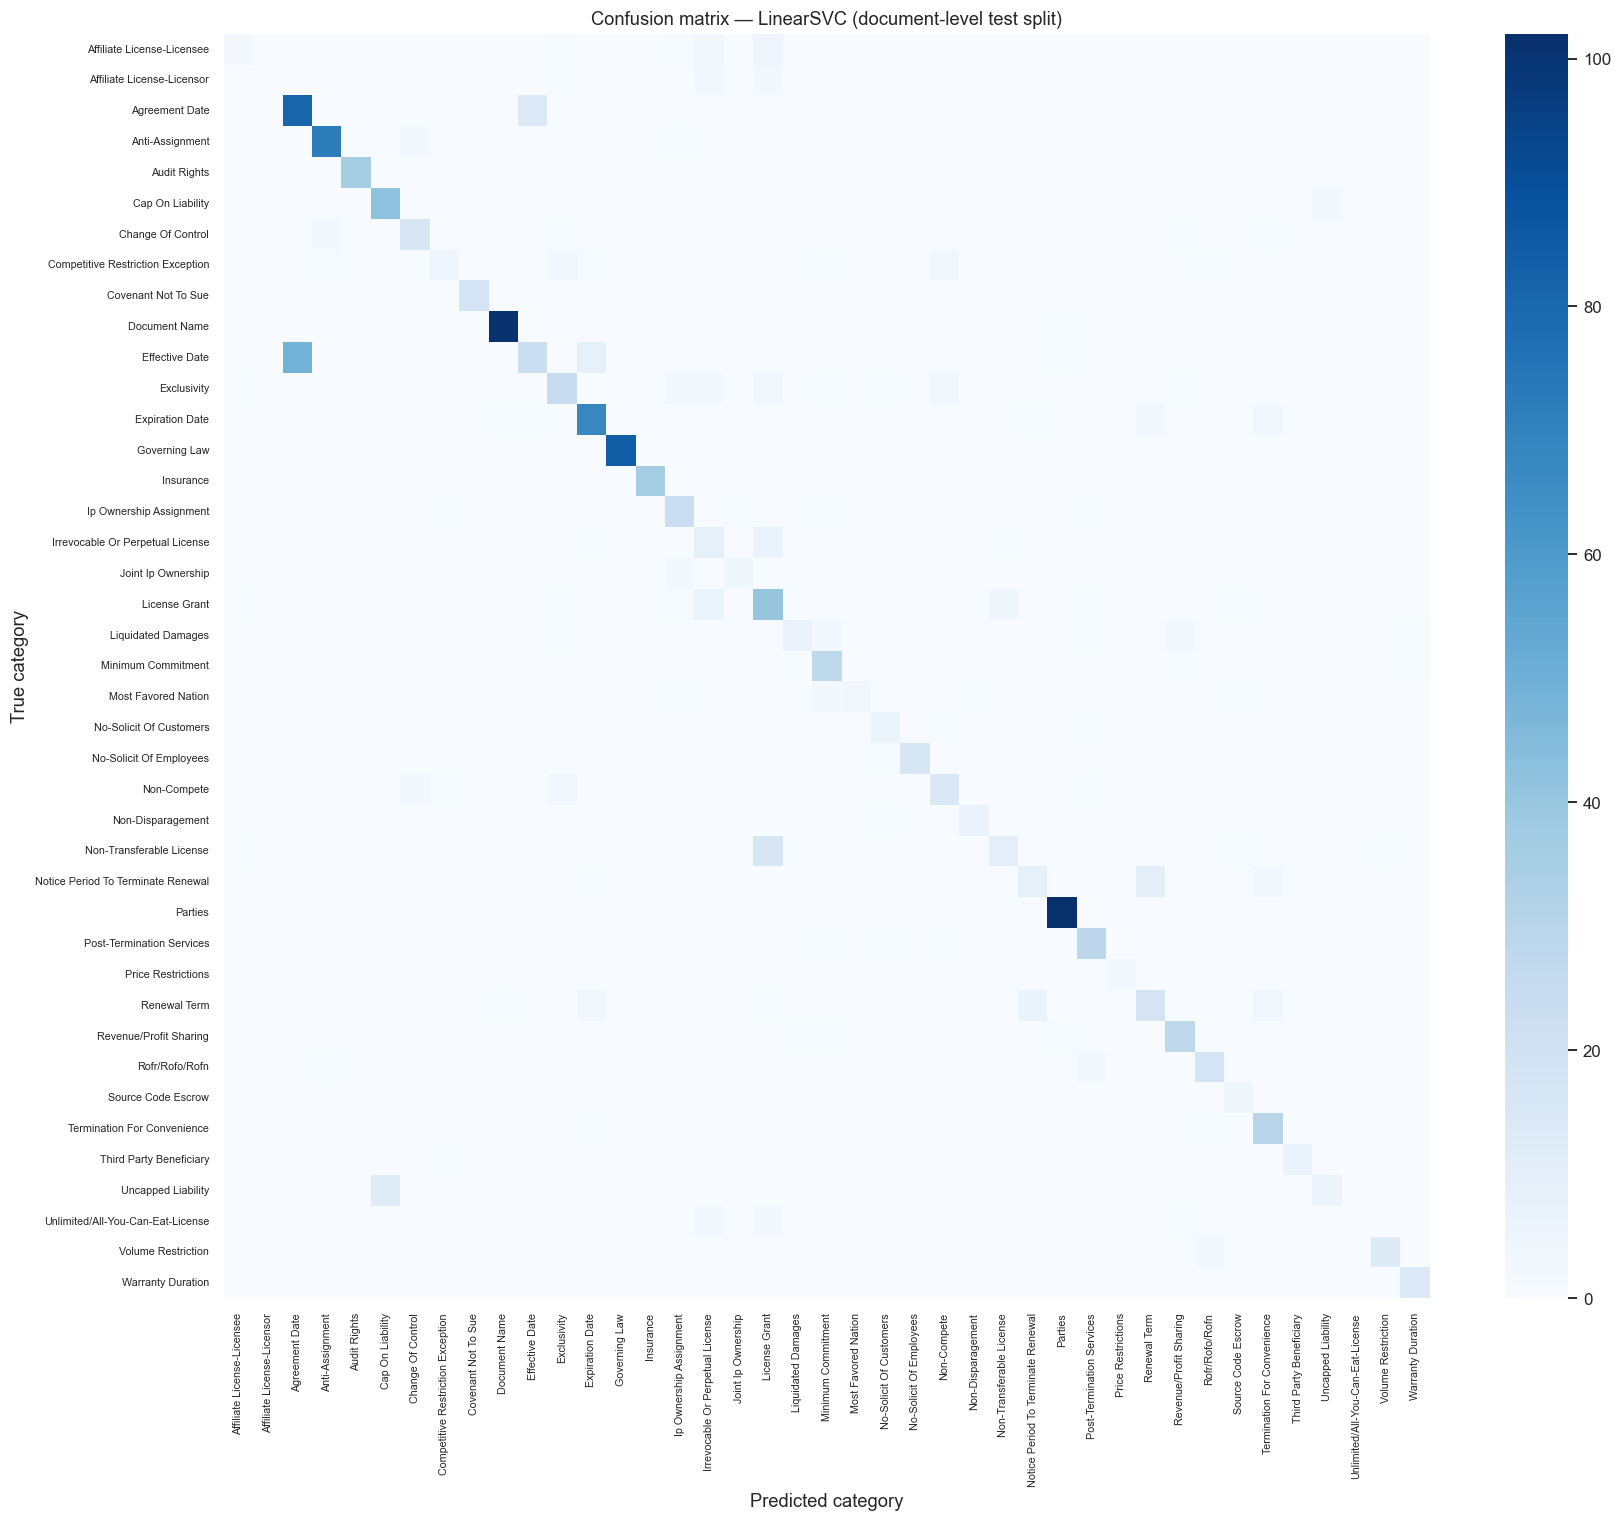

In [12]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, preds, labels=labels)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot=False,
    linewidths=0,
    ax=ax,
)
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
ax.set_title("Confusion matrix — LinearSVC (document-level test split)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


## 8. Per-category evaluation (tuned SVM)

**Interpretation:** Categories with **larger support** (more test examples) often achieve **higher recall**; **rare** categories tend to show **lower recall** unless explicitly weighted — consistent with Part 02 EDA. Legally **similar** headings (e.g. termination vs renewal-style language) can be confused when wording overlaps.

In [13]:
print(classification_report(y_test, preds, zero_division=0))


                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.50      0.23      0.32        13
        Affiliate License-Licensor       0.00      0.00      0.00         5
                    Agreement Date       0.62      0.85      0.72        95
                   Anti-Assignment       0.95      0.96      0.95        75
                      Audit Rights       1.00      1.00      1.00        36
                  Cap On Liability       0.78      0.95      0.86        44
                 Change Of Control       0.81      0.77      0.79        22
 Competitive Restriction Exception       0.62      0.33      0.43        15
               Covenant Not To Sue       1.00      1.00      1.00        18
                     Document Name       0.98      0.99      0.99       102
                    Effective Date       0.61      0.28      0.38        82
                       Exclusivity       0.69      0.64      0.67        39
           

## 9. Error analysis

We inspect **misclassified** real spans: wrong predicted category vs true category. Common patterns:

- **Rare classes:** few training examples → model defaults to frequent labels.
- **Lexical overlap:** clauses about **termination**, **renewal**, or **term** can share boilerplate.
- **Short spans:** little text → weak TF-IDF signal.

Example narrative (adjust after you read samples): *Clauses related to "Termination" and "Renewal" may be confused when both discuss contract end dates in similar phrasing.*

In [14]:
test_idx = y_test.index
wrong = preds != y_test.values
n_wrong = int(wrong.sum())
print("Misclassified (count):", n_wrong, "/", len(y_test))

sample = pd.DataFrame(
    {
        "true": y_test.values[wrong],
        "pred": preds[wrong],
    }
).head(12)
display(sample)

# Pair counts: most confused label pairs (excluding diagonal)
bad_df = pd.DataFrame({"true": y_test.values, "pred": preds})
bad_df = bad_df[bad_df["true"] != bad_df["pred"]]
pair_counts = bad_df.groupby(["true", "pred"]).size().sort_values(ascending=False)
print("Top confused pairs (true → pred):")
display(pair_counts.head(15).to_frame("n"))


Misclassified (count): 267 / 1327


,true,pred
0,Effective Date,Agreement Date
1,Cap On Liability,Uncapped Liability
2,Effective Date,Agreement Date
3,Renewal Term,Notice Period To Terminate Renewal
4,Most Favored Nation,Ip Ownership Assignment
5,Competitive Restriction Exception,Non-Compete
6,Non-Transferable License,License Grant
7,Affiliate License-Licensor,Exclusivity
8,Uncapped Liability,Cap On Liability
9,Effective Date,Agreement Date


Top confused pairs (true → pred):


,,n
true,pred,
Effective Date,Agreement Date,49
Non-Transferable License,License Grant,17
Agreement Date,Effective Date,14
Uncapped Liability,Cap On Liability,12
Notice Period To Terminate Renewal,Renewal Term,10
Effective Date,Expiration Date,9
Irrevocable Or Perpetual License,License Grant,7
Renewal Term,Notice Period To Terminate Renewal,7
License Grant,Irrevocable Or Perpetual License,6


## 10. Final model selection

We adopt **`SVM (GridSearch, tuned C)`** as the **reported Phase 1 model**: `GridSearchCV` picks **`C`** on **macro-F1** (3-fold CV on the training set only), then we evaluate once on the **document-level test split**. This usually beats **fixed `C=1`** on sparse legal text. **Naive Bayes** and **default SVM** stay as **baselines** for comparison.

## 11. Limitations

- **Rare categories:** low support → poor recall unless resampling, weighting, or more data.
- **Corpus size:** 510 contracts; generalization to other jurisdictions or genres is not guaranteed.
- **No deep semantics:** bag-of-words / n-grams miss long-range meaning; **Phase 2** (e.g. BERT-style encoders) targets that gap.
- **Multi-class on category names** is one valid Phase 1 framing; per-category **Yes/No** tasks (Part 03) are another — report which task matches your report claims.

## 12. Conclusion

The **TF-IDF (unigrams–trigrams, higher `max_features`) + linear SVM with `GridSearchCV` on `C`** pipeline, evaluated with **document-level** splits and **macro** metrics, provides a **strong Phase 1 baseline** for clause-type classification on CUAD. Compare against **Naive Bayes** and **default-C SVM** in the results table. This sets the stage for **deep learning** in Phase 2.

---

**Rubric mapping:** model application, metric choice vs imbalance, model comparison, confusion / per-class report, error analysis, limitations — covered in this notebook.